In [79]:
#Importing all the required libraries
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix,classification_report

In [80]:
#loading the data
df = pd.read_csv('data\\children_1.csv')
df

,age,gender,bmi,diet_type,hemoglobin_g_dl,has_night_blindness,has_fatigue,has_pale_skin,has_dry_skin,other_diagnosis,disease_diagnosis
0,7,Male,14.3,omnivorous,14.8,0,1,1,0,Malaria,Healthy
1,12,Male,20.4,omnivorous,12.3,0,0,0,0,No other disease,Healthy
2,15,Male,21.2,omnivorous,13.0,0,1,0,0,Sickle cell,Healthy
3,9,Male,15.5,omnivorous,14.9,0,1,1,0,Malaria,Healthy
4,2,Male,19.7,omnivorous,14.2,1,1,0,1,Malaria,Night_blindness
...,...,...,...,...,...,...,...,...,...,...,...
9995,4,Female,16.2,omnivorous,12.4,0,0,0,0,Sickle cell,Healthy
9996,11,Female,19.3,omnivorous,12.0,0,0,0,0,No other disease,Healthy
9997,11,Male,19.3,omnivorous,13.7,0,0,0,0,No other disease,Healthy
9998,2,Female,15.4,omnivorous,12.5,0,0,0,0,Sickle cell,Healthy


In [81]:
df.columns

Index(['age', 'gender', 'bmi', 'diet_type', 'hemoglobin_g_dl',
       'has_night_blindness', 'has_fatigue', 'has_pale_skin', 'has_dry_skin',
       'other_diagnosis', 'disease_diagnosis'],
      dtype='str')

In [82]:
#An overview of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  int64  
 1   gender               10000 non-null  str    
 2   bmi                  10000 non-null  float64
 3   diet_type            10000 non-null  str    
 4   hemoglobin_g_dl      10000 non-null  float64
 5   has_night_blindness  10000 non-null  int64  
 6   has_fatigue          10000 non-null  int64  
 7   has_pale_skin        10000 non-null  int64  
 8   has_dry_skin         10000 non-null  int64  
 9   other_diagnosis      10000 non-null  str    
 10  disease_diagnosis    10000 non-null  str    
dtypes: float64(2), int64(5), str(4)
memory usage: 1.2 MB


In [83]:
#Statistical summary of the data
df.describe()

,age,bmi,hemoglobin_g_dl,has_night_blindness,has_fatigue,has_pale_skin,has_dry_skin
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,8.916000,17.789480,12.814040,0.196400,0.227800,0.13470,0.167700
std,4.916519,3.097779,1.137378,0.397294,0.419434,0.34142,0.373618
min,1.000000,12.000000,8.000000,0.000000,0.000000,0.00000,0.000000
25%,5.000000,15.500000,12.000000,0.000000,0.000000,0.00000,0.000000
50%,9.000000,17.300000,12.800000,0.000000,0.000000,0.00000,0.000000
75%,13.000000,19.600000,13.600000,0.000000,0.000000,0.00000,0.000000
max,17.000000,31.400000,16.700000,1.000000,1.000000,1.00000,1.000000


In [84]:
#setting configurations of the figures
sns.set_style('whitegrid')

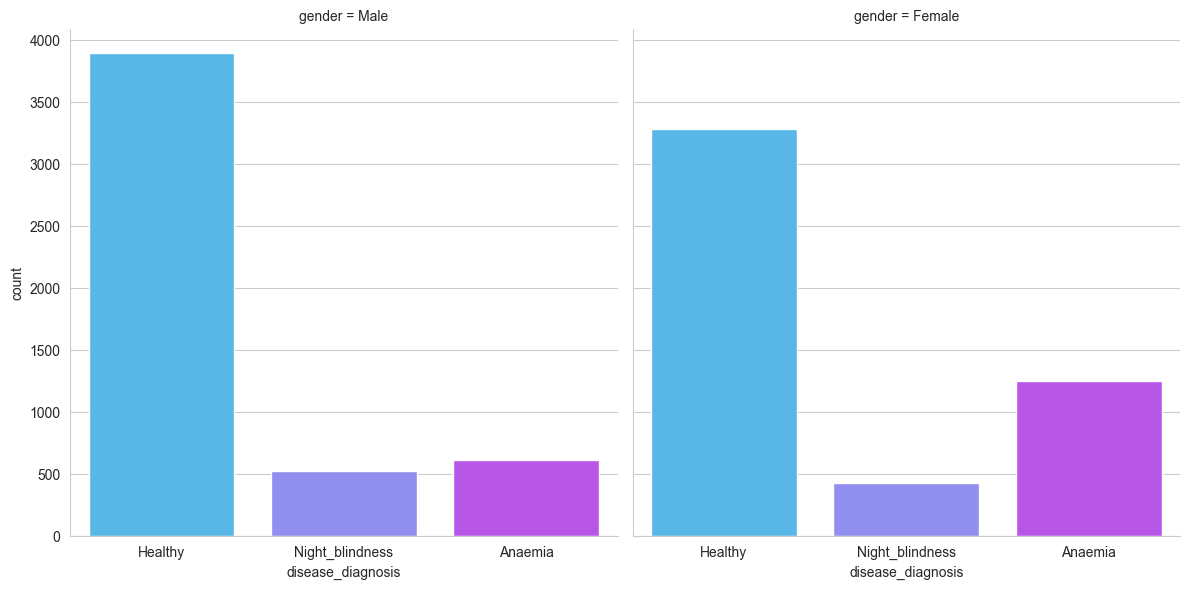

In [85]:
sns.catplot(data=df, x='disease_diagnosis', palette='cool', col='gender', kind='count', height=6)
plt.show()

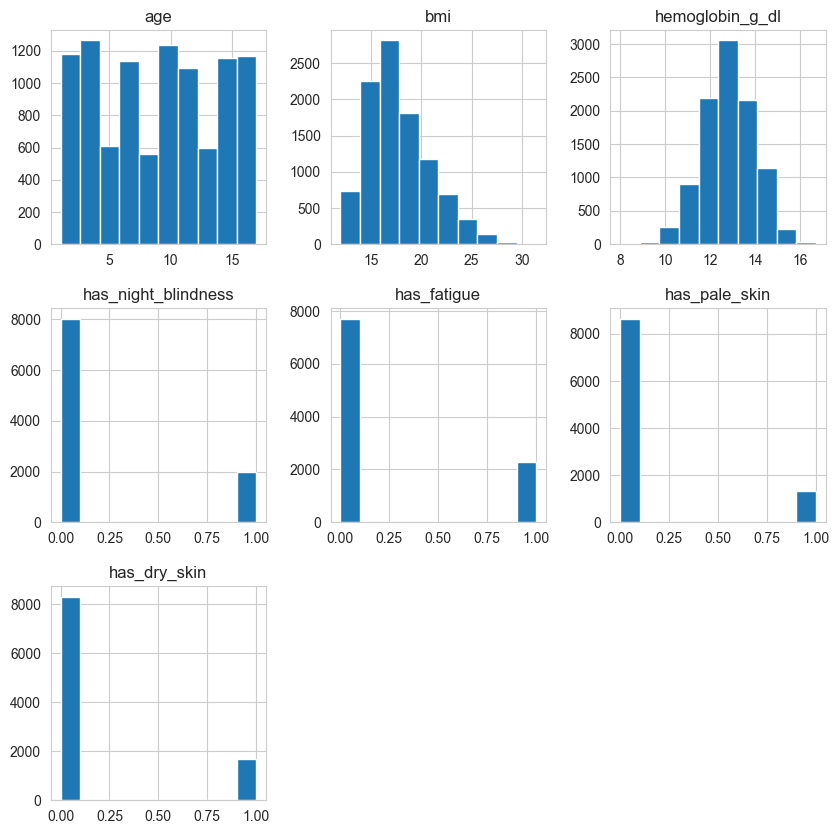

In [86]:
#Data visualization
df.hist(figsize=(10,10))
plt.show()

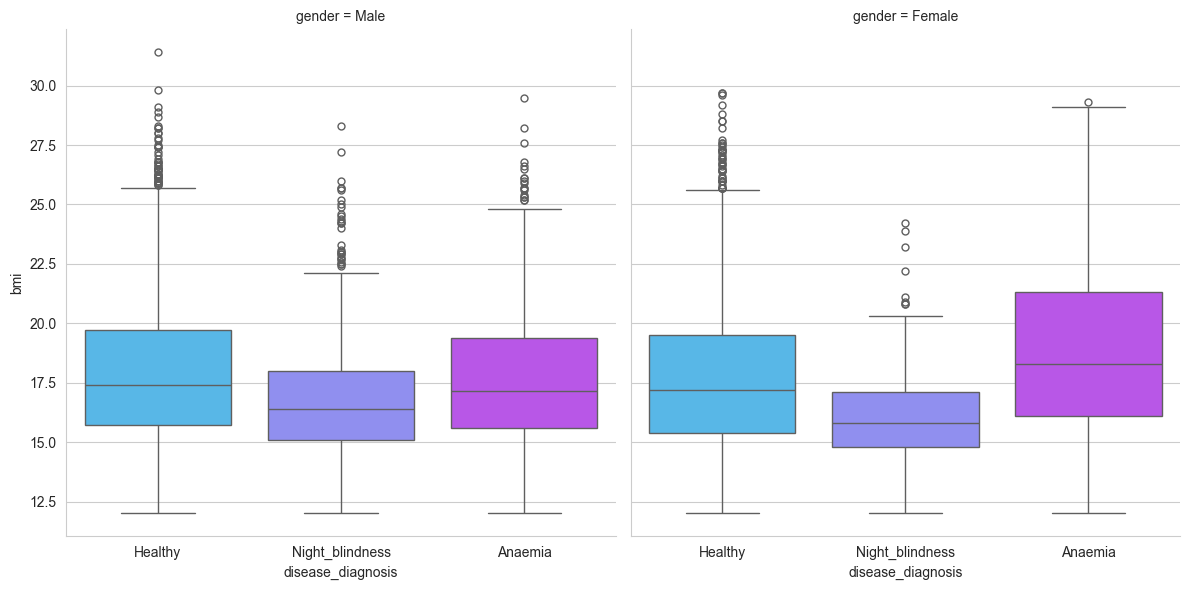

In [87]:

sns.catplot(data=df, y='bmi',x='disease_diagnosis',col='gender',kind='box', palette='cool', height=6, aspect=1)
plt.show()

In [88]:
le = LabelEncoder()
df['disease_diagnosis'] = le.fit_transform(df['disease_diagnosis'])

In [89]:
num= df.select_dtypes(include=np.number)
corr = num.corr()

<Axes: >

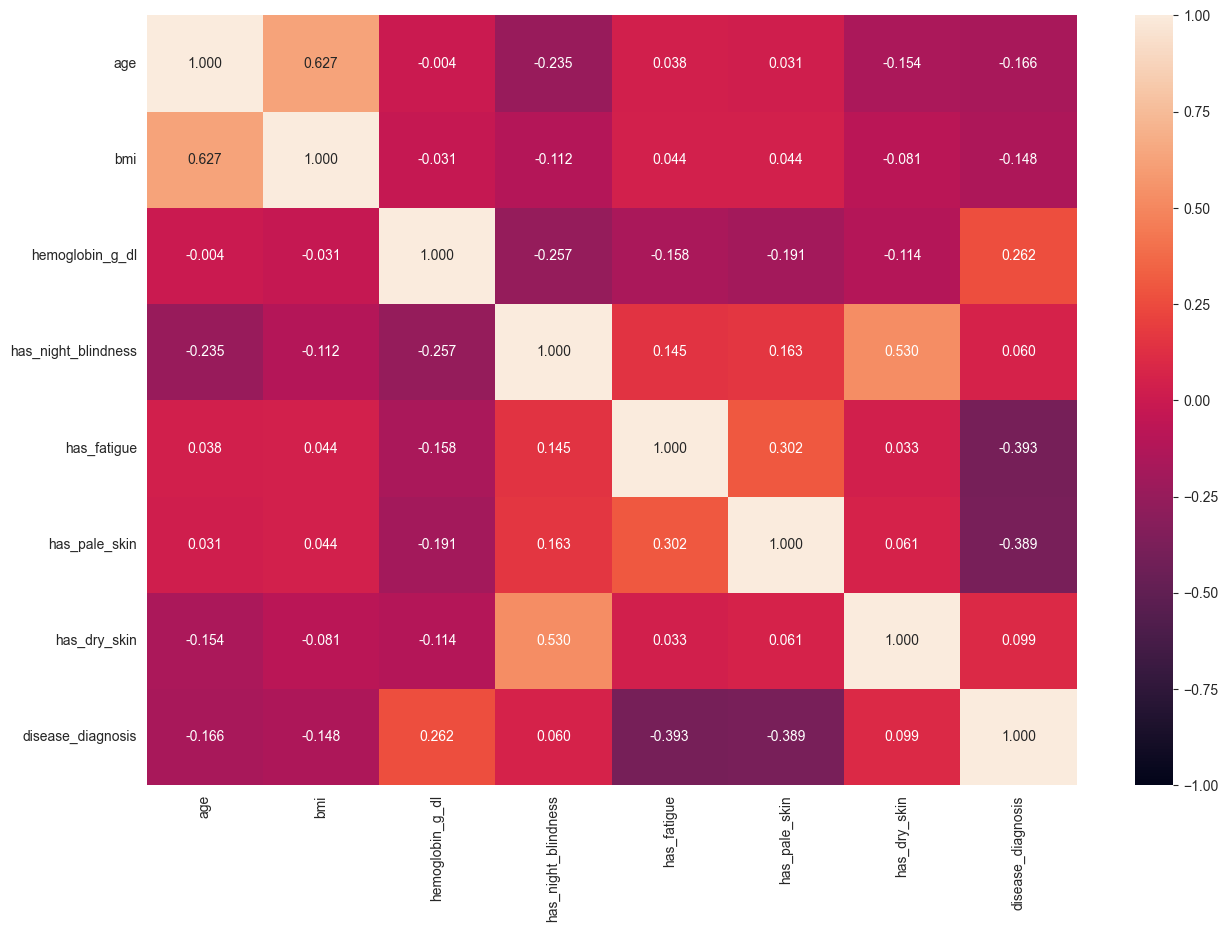

In [90]:
plt.figure(figsize=(15,10))
sns.heatmap(data=corr, annot=True,fmt=".3f",vmin=-1, vmax=1)

In [91]:
y = df.disease_diagnosis
y

0       1
1       1
2       1
3       1
4       2
       ..
9995    1
9996    1
9997    1
9998    1
9999    1
Name: disease_diagnosis, Length: 10000, dtype: int64

In [92]:
df.columns

Index(['age', 'gender', 'bmi', 'diet_type', 'hemoglobin_g_dl',
       'has_night_blindness', 'has_fatigue', 'has_pale_skin', 'has_dry_skin',
       'other_diagnosis', 'disease_diagnosis'],
      dtype='str')

In [93]:
X = df.drop(columns = ['disease_diagnosis'])
X

,age,gender,bmi,diet_type,hemoglobin_g_dl,has_night_blindness,has_fatigue,has_pale_skin,has_dry_skin,other_diagnosis
0,7,Male,14.3,omnivorous,14.8,0,1,1,0,Malaria
1,12,Male,20.4,omnivorous,12.3,0,0,0,0,No other disease
2,15,Male,21.2,omnivorous,13.0,0,1,0,0,Sickle cell
3,9,Male,15.5,omnivorous,14.9,0,1,1,0,Malaria
4,2,Male,19.7,omnivorous,14.2,1,1,0,1,Malaria
...,...,...,...,...,...,...,...,...,...,...
9995,4,Female,16.2,omnivorous,12.4,0,0,0,0,Sickle cell
9996,11,Female,19.3,omnivorous,12.0,0,0,0,0,No other disease
9997,11,Male,19.3,omnivorous,13.7,0,0,0,0,No other disease
9998,2,Female,15.4,omnivorous,12.5,0,0,0,0,Sickle cell


In [94]:
y_classes = le.classes_

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify = y)

In [96]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [97]:
scaler1 = StandardScaler()
scaler = QuantileTransformer()
scaler2 = RobustScaler()
real_scaler = PowerTransformer()

In [98]:
cat_pipe = make_pipeline(encoder, real_scaler)

In [99]:
num_pipe = make_pipeline(real_scaler)

In [100]:
preprocess = make_column_transformer(
    (cat_pipe, make_column_selector(dtype_include=object)),
    (num_pipe, make_column_selector(dtype_include=np.number))
    
)

In [101]:
Lr = LogisticRegression(random_state=2)
tr = DecisionTreeClassifier(random_state=17, class_weight='balanced')
knn = KNeighborsClassifier()
rc = RandomForestClassifier(random_state=42, class_weight='balanced')
Xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

In [102]:
Lr_pipe = make_pipeline(preprocess, Lr)

In [103]:
Tr_pipe = make_pipeline(preprocess, tr)

In [104]:
knn_pipe = make_pipeline(preprocess, knn)

In [105]:
rc_pipe = make_pipeline(preprocess, rc)

In [106]:
Xgb_pipe = make_pipeline(preprocess, Xgb)

In [107]:
title = 'CLASSIFICATION REPORT FOR'

****************************CLASSIFICATION REPORT FOR LOGISTICREGRESSION**************************** 
                 precision    recall  f1-score   support

        Anaemia       0.89      0.79      0.83      1495
        Healthy       0.96      0.98      0.97      5741
Night_blindness       0.90      0.96      0.93       764

       accuracy                           0.94      8000
      macro avg       0.92      0.91      0.91      8000
   weighted avg       0.94      0.94      0.94      8000



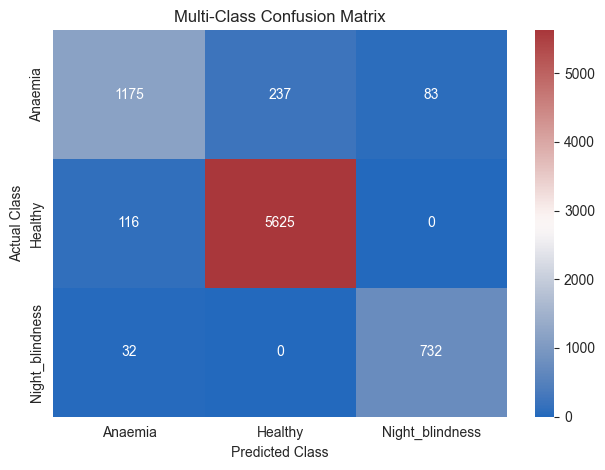

In [108]:
model_1 = "LogisticRegression"
Title_Lr = title + " " + model_1.upper()
clf_Lr = cross_val_predict(Lr_pipe, X_train, y_train, cv= 3)
print(f"{Title_Lr:*^100} ")
print(classification_report(y_true=y_train,y_pred=clf_Lr,target_names=y_classes))
cm_Lr = confusion_matrix(y_true=y_train, y_pred=clf_Lr)


sns.heatmap(
    cm_Lr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR DECISIONTREECLASSIFIER**************************
                 precision    recall  f1-score   support

        Anaemia       0.99      0.99      0.99      1495
        Healthy       1.00      1.00      1.00      5741
Night_blindness       0.99      0.99      0.99       764

       accuracy                           1.00      8000
      macro avg       0.99      0.99      0.99      8000
   weighted avg       1.00      1.00      1.00      8000



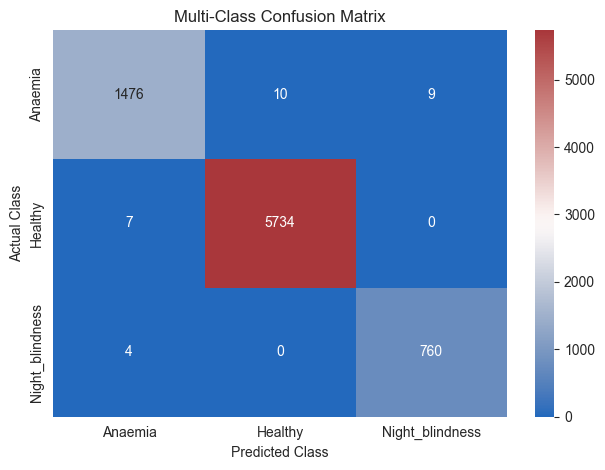

In [109]:
clf_tr = cross_val_predict(Tr_pipe, X_train, y_train, cv= 3)
model_2 = "DecisionTreeClassifier"
Title_tr = title + " " + model_2.upper()
cm_tr = confusion_matrix(y_train, clf_tr)
print(f"{Title_tr:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_tr,target_names=y_classes))
cm_tr = confusion_matrix(y_true=y_train, y_pred=clf_tr)

sns.heatmap(
    cm_tr, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


***************************CLASSIFICATION REPORT FOR KNEIGHBORSCLASSIFIER***************************
                 precision    recall  f1-score   support

        Anaemia       0.95      0.85      0.90      1495
        Healthy       0.97      0.99      0.98      5741
Night_blindness       0.91      0.98      0.94       764

       accuracy                           0.96      8000
      macro avg       0.94      0.94      0.94      8000
   weighted avg       0.96      0.96      0.96      8000



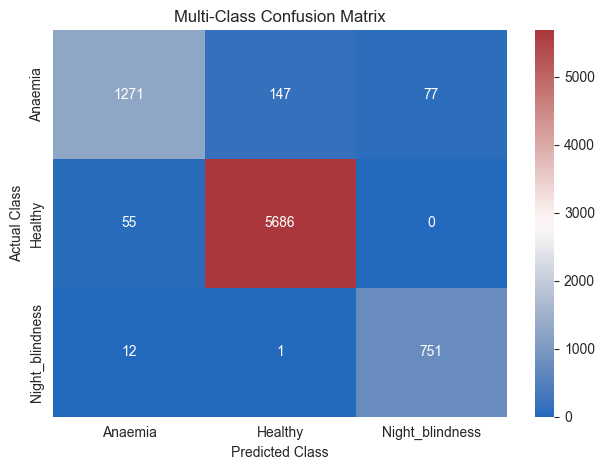

In [110]:
model_3 = "KNeighborsClassifier"
Title_knn = title + " " + model_3.upper()

clf_knn = cross_val_predict(knn_pipe, X_train, y_train, cv= 3)
print(f"{Title_knn:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_knn,target_names=y_classes))
cm_knn = confusion_matrix(y_true=y_train, y_pred=clf_knn)

sns.heatmap(
    cm_knn, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

**************************CLASSIFICATION REPORT FOR RANDOMFORESTCLASSIFIER**************************
                 precision    recall  f1-score   support

        Anaemia       0.99      0.99      0.99      1495
        Healthy       1.00      1.00      1.00      5741
Night_blindness       1.00      1.00      1.00       764

       accuracy                           1.00      8000
      macro avg       1.00      1.00      1.00      8000
   weighted avg       1.00      1.00      1.00      8000



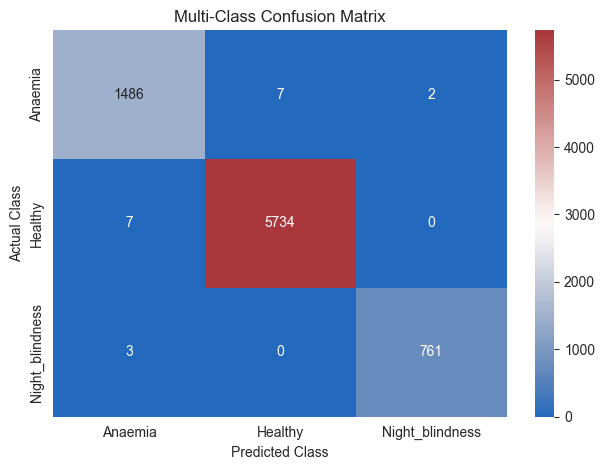

In [111]:
clf_rc = cross_val_predict(rc_pipe, X_train, y_train, cv= 3)
model_4 = "RandomForestClassifier"
Title_rc = title + " " + model_4.upper()
cm_rc = confusion_matrix(y_train, clf_rc)
print(f"{Title_rc:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_rc,target_names=y_classes))
cm_rc = confusion_matrix(y_true=y_train, y_pred=clf_rc)

sns.heatmap(
    cm_rc, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


******************************CLASSIFICATION REPORT FOR XGBCLASSIFIER*******************************
                 precision    recall  f1-score   support

        Anaemia       1.00      1.00      1.00      1495
        Healthy       1.00      1.00      1.00      5741
Night_blindness       1.00      1.00      1.00       764

       accuracy                           1.00      8000
      macro avg       1.00      1.00      1.00      8000
   weighted avg       1.00      1.00      1.00      8000



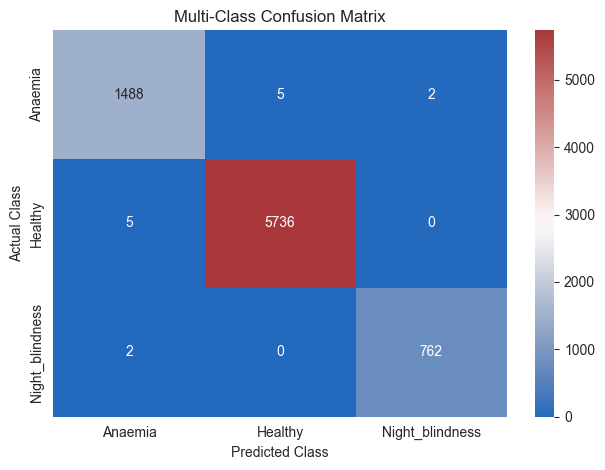

In [112]:
clf_xgb = cross_val_predict(Xgb_pipe, X_train, y_train, cv= 3)
model_4 = "XGBClassifier"
Title_xgb = title + " " + model_4.upper()
cm_xgb = confusion_matrix(y_train, clf_xgb)
print(f"{Title_xgb:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_xgb,target_names=y_classes))
cm_xgb = confusion_matrix(y_true=y_train, y_pred=clf_xgb)

sns.heatmap(
    cm_xgb, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

In [113]:
model = Xgb_pipe
model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('pipeline-1',
                                    Pipeline(steps=[('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False)),
                                                    ('powertransformer',
                                                     PowerTransformer())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x0000028334517050>),
                                   ('pipeline-2',
                                    Pipeline(steps=[('powertransformer',
                                                     PowerTransformer())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x00000283346B0050>)])),
  ('xgbclassifier',
   XGBClassifier(base_sco

In [114]:
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train != 0)
baseline_ratio = num_neg / num_pos

In [115]:
param = {
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
    'xgbclassifier__n_estimators': [50, 100, 200],
    'xgbclassifier__scale_pos_weight': [None,  1, np.sqrt(baseline_ratio), baseline_ratio, baseline_ratio * 1.5 ]
    
}
grid = GridSearchCV(estimator=model, param_grid=param, cv = 3, scoring='accuracy')

In [116]:
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__learning_rate': [0.01, 0.1, ...], 'xgbclassifier__max_depth': [3, 5, ...], 'xgbclassifier__n_estimators': [50, 100, ...], 'xgbclassifier__scale_pos_weight': [None, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the highe

In [117]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__learning_rate': [0.01, 0.1, ...], 'xgbclassifier__max_depth': [3, 5, ...], 'xgbclassifier__n_estimators': [50, 100, ...], 'xgbclassifier__scale_pos_weight': [None, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the highe

In [118]:
pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending= False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__scale_pos_weight,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
82,0.395376,0.016318,0.012179,0.002452,0.10,7,100,0.479399,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas...",0.998125,0.997750,0.999250,0.998375,0.000637,1
81,0.439540,0.066232,0.010506,0.000613,0.10,7,100,1,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas...",0.998125,0.997750,0.999250,0.998375,0.000637,1
83,2.153063,1.170080,0.032092,0.009311,0.10,7,100,0.229823,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas...",0.998125,0.997750,0.999250,0.998375,0.000637,1
80,0.928874,0.271977,0.023563,0.003348,0.10,7,100,None,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas...",0.998125,0.997750,0.999250,0.998375,0.000637,1
84,1.038243,0.687869,0.021250,0.009920,0.10,7,100,0.344735,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas...",0.998125,0.997750,0.999250,0.998375,0.000637,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,0.268745,0.018998,0.011933,0.000578,0.01,3,50,0.229823,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.777653,0.796775,0.788447,0.787625,0.007828,131
0,0.511924,0.298742,0.014256,0.001968,0.01,3,50,None,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.777653,0.796775,0.788447,0.787625,0.007828,131
4,0.277104,0.022217,0.014134,0.002133,0.01,3,50,0.344735,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.777653,0.796775,0.788447,0.787625,0.007828,131
1,0.290225,0.013606,0.016802,0.002953,0.01,3,50,1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.777653,0.796775,0.788447,0.787625,0.007828,131


In [119]:
finished_model = grid.best_estimator_

In [120]:
finished_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

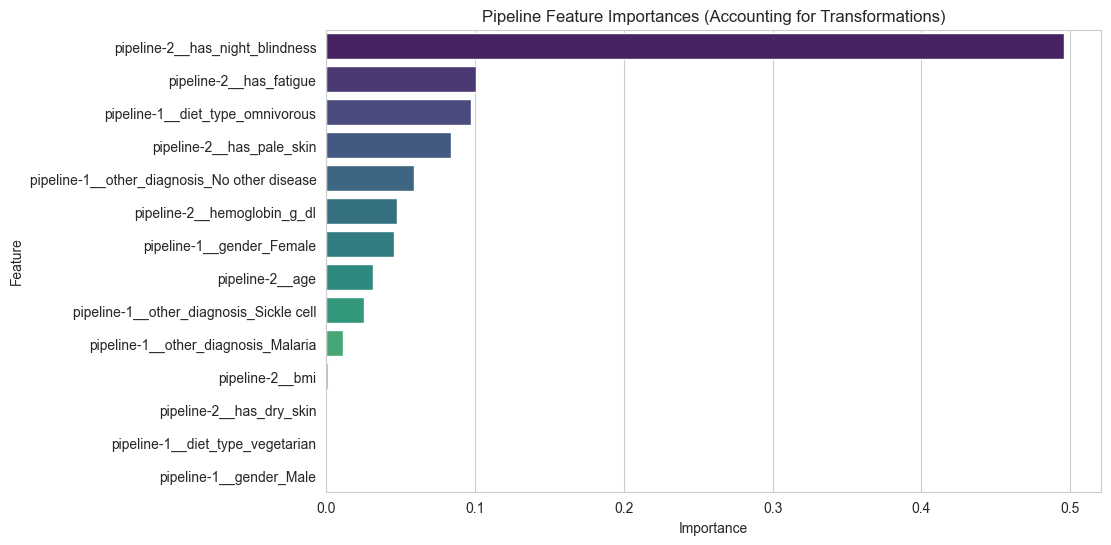

In [121]:
#Feature Importances
tree_model = finished_model.named_steps['xgbclassifier']

feature_names = finished_model.named_steps['columntransformer'].get_feature_names_out()

feature_imp_df = pd.DataFrame({'Feature': feature_names,'Importance': tree_model.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')
plt.title('Pipeline Feature Importances (Accounting for Transformations)')
plt.show()


In [122]:
feature_imp_df

,Feature,Importance
10,pipeline-2__has_night_blindness,0.496013
11,pipeline-2__has_fatigue,0.100729
2,pipeline-1__diet_type_omnivorous,0.097227
12,pipeline-2__has_pale_skin,0.084164
5,pipeline-1__other_diagnosis_No other disease,0.058710
9,pipeline-2__hemoglobin_g_dl,0.047464
0,pipeline-1__gender_Female,0.045642
7,pipeline-2__age,0.031460
6,pipeline-1__other_diagnosis_Sickle cell,0.025654
4,pipeline-1__other_diagnosis_Malaria,0.011565


In [123]:
pred = finished_model.predict(X_test)
pred

array([0, 1, 0, ..., 1, 1, 1], shape=(2000,))

******************************CLASSIFICATION REPORT FOR XGBCLASSIFIER*******************************
                 precision    recall  f1-score   support

        Anaemia       1.00      1.00      1.00      1495
        Healthy       1.00      1.00      1.00      5741
Night_blindness       1.00      1.00      1.00       764

       accuracy                           1.00      8000
      macro avg       1.00      1.00      1.00      8000
   weighted avg       1.00      1.00      1.00      8000



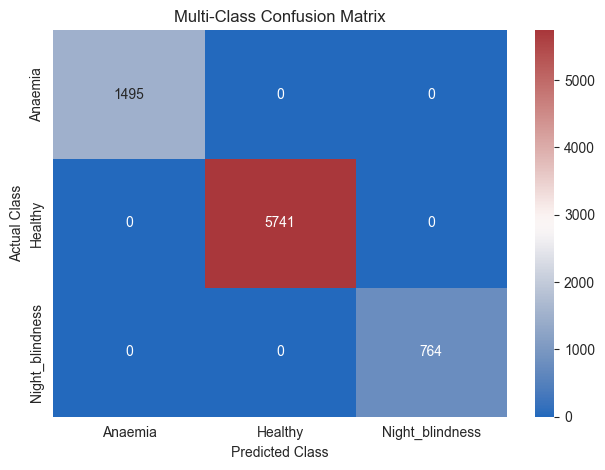

In [124]:
clf_xgb = finished_model.predict(X_train)
model_4 = "XGBClassifier"
Title_xgb = title + " " + model_4.upper()
cm_xgb = confusion_matrix(y_train, clf_xgb)
print(f"{Title_xgb:*^100}")
print(classification_report(y_true=y_train,y_pred=clf_xgb,target_names=y_classes))
cm_xgb = confusion_matrix(y_true=y_train, y_pred=clf_xgb)

sns.heatmap(
    cm_xgb, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

******************************CLASSIFICATION REPORT FOR XGBCLASSIFIER*******************************
                 precision    recall  f1-score   support

        Anaemia       0.99      0.99      0.99       374
        Healthy       1.00      1.00      1.00      1435
Night_blindness       1.00      0.99      1.00       191

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000



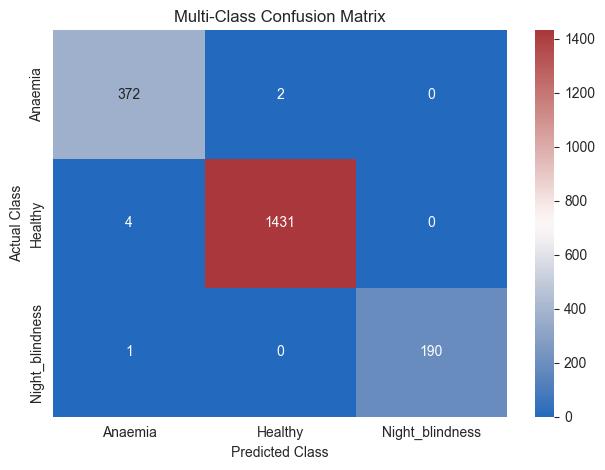

In [125]:
clf_xgb = finished_model.predict(X_test)
model_4 = "XGBClassifier"
Title_xgb = title + " " + model_4.upper()
cm_xgb = confusion_matrix(y_test, clf_xgb)
print(f"{Title_xgb:*^100}")
print(classification_report(y_true=y_test,y_pred=clf_xgb,target_names=y_classes))
cm_xgb = confusion_matrix(y_true=y_test, y_pred=clf_xgb)

sns.heatmap(
    cm_xgb, 
    annot=True, 
    fmt="d", 
    cmap="vlag", 
    xticklabels=y_classes,
    yticklabels=y_classes
)

plt.title("Multi-Class Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

In [126]:
count = 0
predicted = (pred == y_test)
for i in predicted:
    if not i:
        count += 1

In [127]:
if all(predicted):
    print('Yes')
else:
    if count == 1:
        print(f'{count} is False')
    else:
        print(f"{count} are False")
    

7 are False


In [128]:
import joblib

# 1. Saving the final trained pipeline model
joblib.dump(finished_model, 'model.pkl')


# Target classes are: ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
joblib.dump(y_classes, 'classes.pkl')

print("Model assets successfully exported for deployment!")


Model assets successfully exported for deployment!
